# CAPSTONE: Pardavimų ir klientų elgsenos analizė (Supermarket Sales)
### Paruošta: Vytautė Povilanskaitė (Duomenų analitika 12-11-2025)

**Duomenų rinkinys:** Supermarket Sales 
https://www.kaggle.com/datasets/faresashraf1001/supermarket-sales

#### Aplinkos paruošimas

In [32]:
# Įkeliamos visos numatomos reikalingos bibliotekos, vėliau sąrašas gali būti papildytas

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Regresijai
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

#### 1. Duomenų įkėlimas

In [33]:
# Įkeliu duomenis iš aplanko naudodama 'raw string' sprendimą, mano kompiuteryje suveikia visada tvarkingai

df = pd.read_csv(r"C:\Users\linke\Desktop\BIT final lab\SuperMarket Analysis.csv")

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


Duomenys įsikėlė tvarkingai, aiški duomenų struktūra. Pirmos 5 eilutės įrašai logiškai atitinka stulpelių pavadinimus.

#### 2. Duomenų supratimas ir paruošimas

In [34]:
df.shape

(1000, 17)

In [35]:
df.columns.tolist()

['Invoice ID',
 'Branch',
 'City',
 'Customer type',
 'Gender',
 'Product line',
 'Unit price',
 'Quantity',
 'Tax 5%',
 'Sales',
 'Date',
 'Time',
 'Payment',
 'cogs',
 'gross margin percentage',
 'gross income',
 'Rating']

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [37]:
df.isna().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

Matome, kad pirminiai duomenys sudaryti iš 1000 eilučių ir 17 stulpelių. Trūkstamų reikšmių nėra nei viename iš stulpelių. 
Turime skirtingus duomenų tipus: 7 stulpeliai yra float tipo - skaičiai su kableliu, 1 stulpelis int - sveikas skaičius, 9 stulpeliai str - tekstas. Date ir Time reikia pakeisti į datetime.

In [38]:
# Sujungiu Date ir Time į vieną Datetime stulpelį, taip vėliau galėsiu atlikti greitesnę laiko analizę. Atskirus Date ir Time pašalinu dėl triukšmo.

df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%m/%d/%Y %I:%M:%S %p"
)

df = df.drop(columns=["Date", "Time"])

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Payment,cogs,gross margin percentage,gross income,Rating,datetime
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,Ewallet,522.83,4.761905,26.1415,9.1,2019-01-05 13:08:00
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,Cash,76.40,4.761905,3.8200,9.6,2019-03-08 10:29:00
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,Credit card,324.31,4.761905,16.2155,7.4,2019-03-03 13:23:00
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,Ewallet,465.76,4.761905,23.2880,8.4,2019-01-27 20:33:00
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,Ewallet,604.17,4.761905,30.2085,5.3,2019-02-08 10:37:00


In [39]:
# Pridedu stulpelius tolimesnei laiko analizei

df["Hour"] = df["datetime"].dt.hour
df["Weekday"] = df["datetime"].dt.day_name()
df["Month"] = df["datetime"].dt.month

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Payment,cogs,gross margin percentage,gross income,Rating,datetime,Hour,Weekday,Month
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,Ewallet,522.83,4.761905,26.1415,9.1,2019-01-05 13:08:00,13,Saturday,1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,Cash,76.40,4.761905,3.8200,9.6,2019-03-08 10:29:00,10,Friday,3
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,Credit card,324.31,4.761905,16.2155,7.4,2019-03-03 13:23:00,13,Sunday,3
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,Ewallet,465.76,4.761905,23.2880,8.4,2019-01-27 20:33:00,20,Sunday,1
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,Ewallet,604.17,4.761905,30.2085,5.3,2019-02-08 10:37:00,10,Friday,2


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   str           
 1   Branch                   1000 non-null   str           
 2   City                     1000 non-null   str           
 3   Customer type            1000 non-null   str           
 4   Gender                   1000 non-null   str           
 5   Product line             1000 non-null   str           
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Sales                    1000 non-null   float64       
 10  Payment                  1000 non-null   str           
 11  cogs                     1000 non-null   float64       
 12  gross margin percentage  1000 non-null   float

In [41]:
df.select_dtypes(include="number").columns

Index(['Unit price', 'Quantity', 'Tax 5%', 'Sales', 'cogs',
       'gross margin percentage', 'gross income', 'Rating', 'Hour', 'Month'],
      dtype='str')

Po duomenų paruošimo lentelė atrodo taip:
1000 eilučių, 19 stulpelių. 

Duomenų tipai: 
Invoice ID - tekstas;
Branch - tekstas;
City - tekstas;
Customer type - tekstas;
Gender - tekstas;
Product line - tekstas;
Unit price - skaičius po kablelio;
Quantity - sveikas skaičius;
Tax 5% - skaičius po kablelio;
Sales - skaičius po kablelio;
Payment - tekstas;
cogs - skaičius po kablelio;
gross margin percentage - skaičius po kablelio;
gross income - skaičius po kablelio;
Rating - skaičius po kablelio;
datetime (Data ir laikas) - datetime;
Hour - sveikas skaičius;
Weekday - tekstas;
Month - sveikas skaičius.

10 stulpelių turi skaitines reikšmes. 


#### 3. Aprašomoji analizė (EDA)

In [42]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Unit price,1000.0,55.67213,10.08,32.875,55.23,77.935,99.96,26.494628
Quantity,1000.0,5.51,1.0,3.0,5.0,8.0,10.0,2.923431
Tax 5%,1000.0,15.379369,0.5085,5.924875,12.088,22.44525,49.65,11.708825
Sales,1000.0,322.966749,10.6785,124.422375,253.848,471.35025,1042.65,245.885335
cogs,1000.0,307.58738,10.17,118.4975,241.76,448.905,993.0,234.17651
gross margin percentage,1000.0,4.761905,4.761905,4.761905,4.761905,4.761905,4.761905,0.0
gross income,1000.0,15.379369,0.5085,5.924875,12.088,22.44525,49.65,11.708825
Rating,1000.0,6.9727,4.0,5.5,7.0,8.5,10.0,1.71858
datetime,1000,2019-02-14 15:30:27.480000,2019-01-01 10:39:00,2019-01-24 17:58:45,2019-02-13 17:37:00,2019-03-08 15:29:30,2019-03-30 20:37:00,NaN
Hour,1000.0,14.91,10.0,12.0,15.0,18.0,20.0,3.186857


In [43]:
# Atskirai suskaičiuojame medianą

df[["Sales", "Quantity"]].median()

Sales       253.848
Quantity      5.000
dtype: float64

Prieš smulkesnę skaitinių kintamųjų analizę svarbu paminėti, kad pirminė greita apžvalga rodo gerus ir tvarkingus duomenis visoms skaitinėms reikšmėms, išskyrus gross margin percentage, Tax 5% ir gross income. Gross margin percentage identiškas visose išraiškose, t.y. tiek vidurkis, tiek percentiliai, tiek min ir max reikšmės yra lygios 4,76. Nėra realistiška, kad marža visiems pardavimams yra identiška, tačiau žinome, kad duomenys yra sintetiniai ir ji greičiausiai yra tiesiog nustatyta šiam duomenų rinkiniui. Tax 5% ir gross income yra identiški: šiame duomenų rinkinyje Tax 5% yra 5% nuo cogs (Cost Of Goods Sales), o gross income yra Sales – cogs. Reikšmės identiškos, nors tiria ir skirtingus kintamuosius. Vertinsime atsargiai, tačiau iš rinkinio nešalinsime. 

Nors pardavimai atlikti Myanmar šalyje, o jų valiuta yra kyat (MMK), iš šios lentelės jau aiškiai matome, kad naudota valiuta nebuvo Ks. 1 EUR atitinka maždaug 3500-4000 Ks, o visos mūsų piniginės vertės yra žymiai mažesnės. Greičiausiai tai JAV doleriai USD arba Svarai sterlingai GBP, bet kadangi nežinome tikros valiutos, toliau tiesiog vadinsime valiutos vienetais. 

Smulkiau išanalizuokime Sales ir Quantity kintamuosius:

Sales(pardavimai): mean - 322.97, median - 253.85, std - 245.86, min - 10.68, max - 1042.65

Quantity(kiekis): mean - 5.51, median - 5, std - 2.92, min - 1, max - 10

Quantity metrikos rodo gana normalius pasiskirstymus, tačiau Sales metrikos jau signalizuoja apie galimą nenormalų pasiskirstymą ir outliers įtaką. Mediana daug mažesnė už vidurkį, didelis std. Toliau detaliau pažiūrėsime grafikų pagalba.

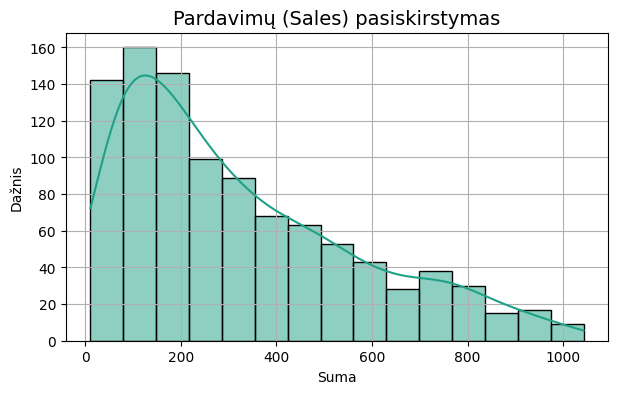

In [44]:
# 1. Grafikas: Histograma su KDE (Pardavimų pasiskirstymas)

plt.figure()
sns.histplot(df['Sales'], kde=True, color=sns.color_palette("viridis")[3])
plt.title('Pardavimų (Sales) pasiskirstymas', fontsize=14)
plt.xlabel('Suma')
plt.ylabel('Dažnis')
plt.show()

Grafikas rodo dešininį pasiskirstymą, t.y. pardavimų tankis didžiausias ties mažesne bendra pardavimų suma ~100 valiutos vienetų. Sumai didėjant, pardavimų dažnis tolydžiai mažėja, ties didelėmis sumomis turime outliers. Daugiausiai pardavimų yra iki 300, tai rodo, kad prekybos centras remiasi pirkimais "mažu krepšeliu", o dideli pirkimai yra daugiausiai pavieniai. Pasiskirstymas nėra normalusis, mediana tampa tikslesniu rodikliu nei vidurkis. Todėl EDA tiriant tipinio pirkėjo elgseną pagal pardavimus naudosime medianą, o vidurkį naudosime bendroms sumoms ir verslo apimtims analizuoti.

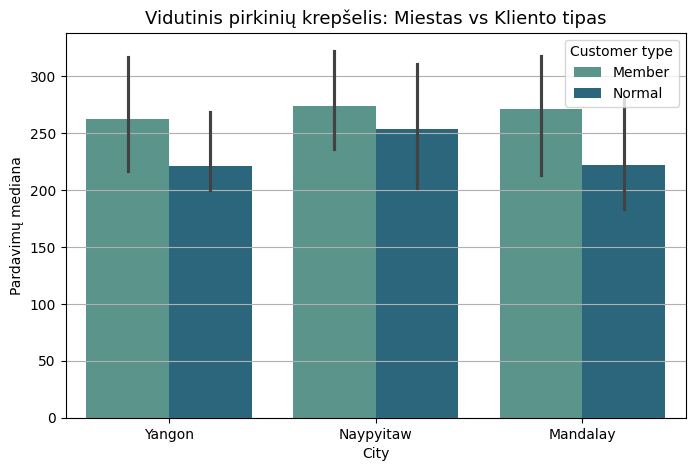

In [45]:
# 2. Grafikas: Pardavimų efektyvumas pagal miestą ir kliento tipą
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='City', y='Sales', hue='Customer type', palette='crest', estimator=np.median)
plt.title('Vidutinis pirkinių krepšelis: Miestas vs Kliento tipas', fontsize=13)
plt.ylabel('Pardavimų mediana')
plt.show()

Gilesniam supratimui pažiūrėjome, ar egzistuoja skirtumas tarp paprastų pirkėjų ir narių. Matome, kad visuose miestuose didesnė krepšelio mediana yra tarp narių, t.y. registruotų vartotojų/ lojalių pirkėjų. 

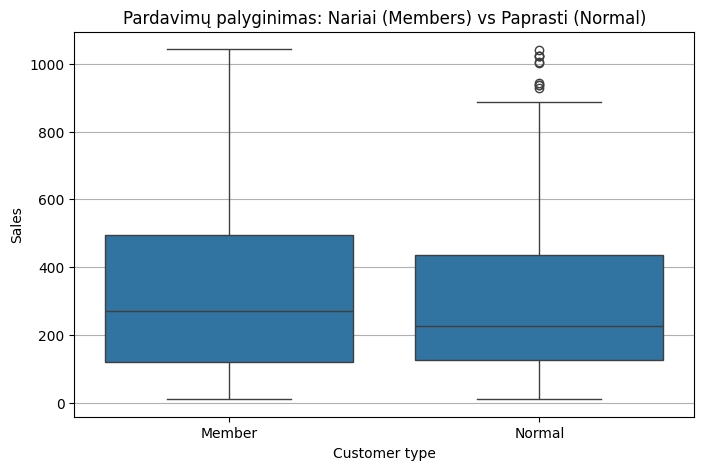

In [46]:
#3. Grafikas: Pardavimų palyginimas tarp narių ir paprastų pirkėjų per boxplot

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Customer type",
    y="Sales"
)

plt.title("Pardavimų palyginimas: Nariai (Members) vs Paprasti (Normal)")
plt.show()

Analizuodami boxplot diagramas matome, kad Normal grupėje yra daug brangių išskirčių (outliers), pirkimų sumos arba bendrai mažesnės už narių, arba atsitiktinai labai didelės, tuo tarpu Members grupėje išskirčių nematyti, pirkimai stabilesni, nors sklaida didesnė. Tai reiškia, kad nariai perka stabiliau, jų pirkinių sumos yra įvairesnės, bet be didelių atsitiktinių išskirčių. Medianos dar kartą patvirtina dešininį pasiskisrtymą abejose grupėse. 

Atsargiai galima daryti prielaidą, kad šis skirtumas gali būti reikšmingas vertinant, ar nariai iš tiesų generuoja didesnę vertę. Vėliau tai statistiškai patikrinsime naudodami T-testą. Nors skirstinio pasiskirstymas ir  nėra normalusis, dėl pakankamai didelės imties (n=1000) vidurkių pasiskirstymas vis tiek bus artimas normaliajam ir T-testas bus pakankamai tikslus. O kad būtume absoliučiai tikri, apsidraudimui panaudosime Mann-Whitney U testą.

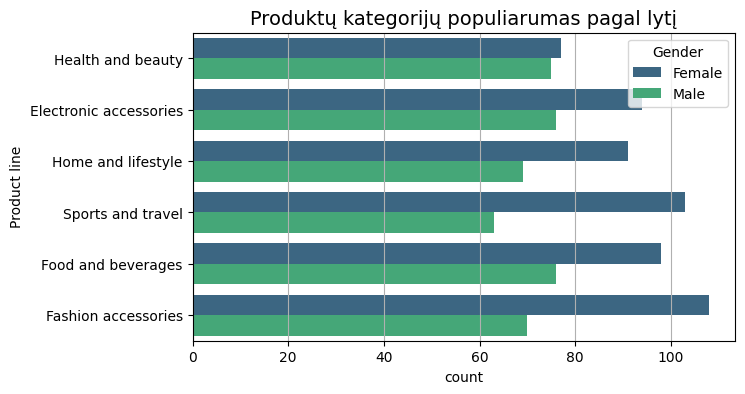

In [47]:
# 4. Grafikas: Produktų linijų populiarumas pagal lytį
plt.figure()
sns.countplot(data=df, y='Product line', hue='Gender', palette="viridis")
plt.title('Produktų kategorijų populiarumas pagal lytį', fontsize=14)
plt.show()

Dėl smalsumo patikrinome ir produktų kategorijų populiarumą pagal lytį. Iš grafiko aiškiai matome, kad moterys nuperka daugiau prekių visose kategorijose palyginus su vyrais. Matome gana didelį skirtumą tarp lyčių dvejose kategorijose: Sports and travel, bei Fashion accessories. Mažiausias vizualus skirtumas yra Health and beauty kategorijoje, čia skirtumas labai nežymus. Kadangi neturime produktų informacijos, negalime detaliau patyrinėti kokius būtent produktus vyrai ir moterys perka daugiau. Tokia analizė būtų labai įdomi, tačiau šiuo atveju galime padaryti tik paprastas įžvalgas apie kategorijas.

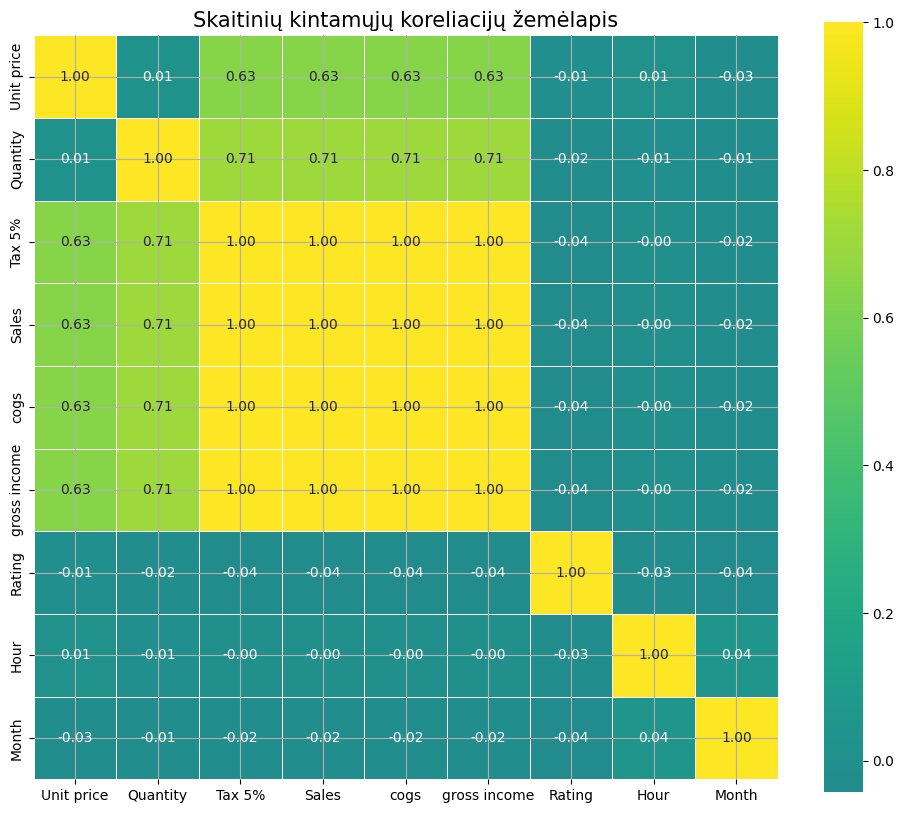

In [48]:
# 5. Grafikas: Kintamųjų tarpusavio koreliacijų žemėlapis (Heatmap)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

to_drop = ['gross margin percentage'] 

final_cols = [col for col in numeric_cols if col not in to_drop]

corr_matrix = df[final_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='viridis',
            center=0, 
            square=True, 
            linewidths=.5)

plt.title('Skaitinių kintamųjų koreliacijų žemėlapis', fontsize=15)
plt.show()

Prieš tolimesnę analizę smalsu pažiūrėti, kokios koreliacijos egzistuoja tarp turimų skaitinių reikšmių. Iš lentelės pašalinau 'gross margin percentage', nes tai yra konstanta, neturinti įtakos variacijų analizei. Taip pat matome multikolinearumą (bei tobulą 1.00 koreliaciją) tarp Sales, Tax 5%, cogs ir gross income. Tai yra vieni iš kitų išvestiniai kintamieji, ir juos vertinti tarpusavy reikia atsargiai. Kol kas jie atrodo kaip triukšmas, duomenų perteklius, tačiau vėliau regresinėje analizėje juos reikės atmesti, kitaip jie gali supainioti modelį. 

Kol kas tiesiog galime teigti, jog matome stiprią teigiamą koreliaciją tarp Sales ir Quantity, bei vidutinę teigiamą koreliaciją tarp Sales ir Unit price. Detalesnei analizei mums reiks įtraukti ir kategorinius kintamuosius.

#### 4. 95 % pasikliautinis intervalas (CI)

##### Apskaičiuojame pasikliautinį intervalą 'Rating' kintamąjam. Tai leis mums įvertinti, kokiame tiksliai intervale varijuoja tikrasis pasitenkinimas paslaugomis.

In [49]:

col = "Rating" 
x = df[col].dropna().astype(float).values
n = len(x)
mean = x.mean()
std = x.std(ddof=1)

alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
se = std / np.sqrt(n)

ci_low = mean - t_crit * se
ci_high = mean + t_crit * se

print(f"Vidurkis: {mean:.2f}")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")


Vidurkis: 6.97
95% CI: [6.87, 7.08]


Gautas rezultatas [6.68, 7.08] rodo, kad esame 95 % tikri, jog tikrasis visų galimų pirkėjų įvertinimų vidurkis patenka į šį diapazoną. Nors atskiri pirkėjai gali vertinti prekybos centrą įvairiai, ir jį vertino nuo 4(min) iki 10(max), bendras stabilus pasitenkinimo lygis svyruoja aplink 6.97 balo. Jeigu skalė yra standartiškai nuo 1 iki 10, tai teorinis vidurkis būtų 5.5. Gautas 6.97 vidurkis rodo, kad bendras pirkėjų pasitenkinimas yra teigiamas (viršija skalės vidurį – 5.5 balo), ir nors balas nėra labai aukštas, nebuvo ir žemesnių nei 4 balų įvertinimų. Galima teigti, kad pasitenkinimas yra vidutinis su galimybe nesunkiai kilstelti balą aukščiau, juolab kad viršutinė pasikliautinio intervalo reikšmė jau viršija 7 balus.

#### 5. Hipotezių testavimas (H0 ir Ha)

Hipotezių testavimui atlikti naudosime 'Sales' kintamąjį ir tikrinsime ar egzistuoja statistiškai reikšmingas skirtumas tarp 'Member' ir 'Normal' pirkėjų vidutinių pirkimų sumų. Skaičiavimui naudosime T-testą (Welsh), o rezultatams patikrinti panaudosime ir Mann_withney U metodą. Tokį pasirinkimą lėmė kintamojo 'Sales' skirstinio dešininis pasiskirstymas. Dėl didelės imties (n=1000) ir CLT, darome prielaidą, kad skirstiniai bus artimi normaliesiems, ir tai tenkina T-testo reikalavimus. Po to dar patikrinsime su Mann_Whitney U, kuris tikrina, ar vienos grupės reikšmės linkusios būti didesnės už kitos naudodamas rangus/pasiskirstymą, ir nereikalauja normaliojo skirstinio.

1. Hipotezių formulavimas:

- H0 (Nulinė hipotezė): Vidutinės pirkimo sumos (Sales) tarp „Member“ ir „Normal“ klientų grupių nesiskiria.

- Ha (Alternatyvioji hipotezė): Vidutinės pirkimo sumos (Sales) tarp „Member“ ir „Normal“ klientų grupių statistiškai reikšmingai skiriasi.

2. Hipotezių testavimas su Welsh T-test:

In [50]:
group = "Customer type"
target = "Sales"

g_member = df.loc[df[group] == "Member", target]
g_normal = df.loc[df[group] == "Normal", target]

t_stat, p_val = stats.ttest_ind(g_member, g_normal, equal_var=False)

mean_member = g_member.mean()
mean_normal = g_normal.mean()
diff_means = mean_member - mean_normal

print(f"t-statistika: {t_stat:.4f}")
print(f"p-reikšmė: {p_val:.4f}")
print(f"Member vidurkis: {mean_member:.2f}")
print(f"Normal vidurkis: {mean_normal:.2f}")
print(f"Skirtumas: {diff_means:.2f}")

t-statistika: 1.8862
p-reikšmė: 0.0596
Member vidurkis: 335.74
Normal vidurkis: 306.37
Skirtumas: 29.37


Pritaikius T-testą matome rezultatus ties riba. Kadangi p-reikšmė yra didesnė už pasirinktą reikšmingumo lygmenį (alpha = 0.05), nulinės hipotezės (H0) neatmetame, ir galime teigti, jog vidutinės pirkimo sumos tarp 'Member' ir 'Normal' grupių nesiskiria. Tačiau p-reikšmė yra labai artima alpha reikšmei, o žinant, jog skirstinys turi dešinįjį pasiskirstymą, svarbu atlikti Mann-Withney U testą. 

In [51]:
# Atliekame Shapiro-Wilk testą
shapiro_stat, shapiro_p = stats.shapiro(df['Sales'])

print("--- Shapiro-Wilk testo rezultatai ---")
print(f"Statistika: {shapiro_stat:.4f}")
print(f"p-reikšmė: {shapiro_p:.10f}")

# Rezultato interpretacija
if shapiro_p > 0.05:
    print("\nIšvada: Duomenys yra pasiskirstę normaliai (p > 0.05).")
else:
    print("\nIšvada: Duomenys NĖRA pasiskirstę normaliai (p <= 0.05).")

--- Shapiro-Wilk testo rezultatai ---
Statistika: 0.9088
p-reikšmė: 0.0000000000

Išvada: Duomenys NĖRA pasiskirstę normaliai (p <= 0.05).


Dar kartą įsitikiname, kad skirstinys nėra normalusis su Shapiro-Wilk testu. Toliau tęsiame su Mann Whitney U.

In [52]:
u_stat, p_val_mw = stats.mannwhitneyu(g_member, g_normal, alternative='two-sided')

median_member = g_member.median()
median_normal = g_normal.median()

print(f"Mann-Whitney U statistika: {u_stat:.2f}")
print(f"Mann-Whitney p-reikšmė: {p_val_mw:.4f}")
print(f"Member mediana: {median_member:.2f}")
print(f"Normal mediana: {median_normal:.2f}")

Mann-Whitney U statistika: 130784.00
Mann-Whitney p-reikšmė: 0.0812
Member mediana: 271.95
Normal mediana: 225.79


Pastarasis skaičiavimas mums patvirtino, kad negalime atmesti H0 hipotezės. Nors p-reikšmė (0.0812) yra maža, ji vis tiek viršija standartinę alpha=0.05 ribą. Tai reiškia, kad statistiškai reikšmingo skirtumo tarp grupių nėra, nors praktinis skirtumas ir akivaizdus.

Praktinis vidurkių skirtumas atitinka 29.37 valiutos vienetus, medianos net 46.16 valiutos vienetų. Nors statistiškai tai nėra svarbu, beveik 30 valiutos vnt didesnis vidutinis 'Member' krepšelis ir 46.16 mediana sako savininkams, kad jie visgi perka truputį brangiau. Priklausomai nuo strategijos, šie duomenys gali padėti nuspręsti, ar verta sustiprinti lojalumo programą ir pasiekti statistiškai svarbią ribą, ar lojalumo programos atsisakyti. Analitikui veikiausiai kiltų mintis paskaičiuoti daugiau ir giliau, pasigilinti į produkto analizę pagal kategorijas ir panašiai. Tarp atskirų kategorijų skirtumas gali būti statistiškai reikšmingas, tačiau kad neapkrautume šio darbo, su hipotezių tikrinimu čia ir sustosime, toliau judėsime su regresine analize ir prognozavimu, kas leis įvertinti, kaip sąveika tarp miesto, prekių kategorijos ir pirkimo laiko bendrai veikia galutinę apyvartą. 

#### 6. Regresinė analizė

Atliksime regresinę analizę, kad įvertintume, kiek 'Sales' kintamojo paaiškina kiti duomenų kintamieji. Į modelį dėl tobulos koreliacijos su 'Sales' neįtraukiame 'cogs', 'Tax 5%' ir 'gross income'. Įtraukiame 'Unit price', 'Quantity' (iš esmės jau žinome, kad šie du kintamieji paaiškins didžiąją dalį modelio); įtraukiame 'Branch', bet ne 'City', nes jau žinome, kad jie atspindi tuos pačius duomenis; įtraukiame 'Customer type', nors iš esmės jau žinome, kad statistinio reikšmingumo tarp kitamųjų nėra, tačiau tai padės pamatyti ar Dummies buvo sukurti teisingai; įtraukiame 'Gender' nes žinome, kad moterys paprastai nuperka daugiau už vyrus; įtraukiame 'Product line' ir 'Payment' nes juos kol kas tyrėme mažai ir jų reikšmė dar nėra aiški; įtraukiame 'Hour' dėl smalsumo, nors iš koreliacijos matricos jau žinome, kad laiko kintamieji beveik neturėjo jokios koreliacijos su 'Sales' kintamuoju, dėl šios priežasties, kad neapkrautume modelio, neįtraukiame nei 'Month', nei 'Weekday'.

In [53]:
# 1. Pasirenkame target ir features
target = "Sales"
feature_cols = ["Unit price", "Quantity", "Branch", "Customer type", "Gender", "Product line", "Payment", "Hour"]

X_raw = df[feature_cols].copy()
y = df[target].astype(float)

# 2. Dummy kintamieji ir float konvertavimas 
X = pd.get_dummies(X_raw, drop_first=True).astype(float)

# 3. Duomenų skaidymas į Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. OLS modelio apmokymas
# Pridedame konstantą (intercept), nes statsmodels to nedaro automatiškai
X_train_ols = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_ols).fit()

# Modelio suvestinė (koeficientams pamatyti)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     441.9
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                        12:40:04   Log-Likelihood:                -4656.8
No. Observations:                 800   AIC:                             9344.
Df Residuals:                     785   BIC:                             9414.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

Regresinė analizė mums parodė, kad modelio kokybė yra labai aukšta, R2 rodiklis yra 0.887, t.y. modelis paaiškina 88.7% pardavimų variacijos. Likę 11% priklauso nuo į modelį neįtrauktų arba nežinomų veiksnių. Modelis mums taip pat parodė, kad P > |t| > 0.05 yra tik dviems kintamiesiems: 'Unit price' ir 'Quantity', t.y. tik šie kintamieji statistiškai reikšmingai paaiškina pardavimų 'Sales' kintamąjį. Tai paprasčiausiai reiškia, kad kuo daugiau ir kuo brangesnių prekių pirkėjai nuperka, tuo labiau didėti yra linkę pardavimai. Quantity yra pats įtakingiausias kintamasis, koeficientas 58.09 reiškia, kad pirkėjui į krepšelį įdėjus vieną papildomą prekę, bendra pardavimų suma vidutiniškai padidėja 58,09 piniginių vienetų (laikant kitus veiksnius nepakeistus), o vieneto kainos 'Unit price' koeficientas 5.82 rodo, kad prekės vieneto kainai pakilus 1 piniginiu vnt, galutinė pardavimo suma vidutiniškai padidėja 5,82 piniginiu vienetu. Nei lojalumo programa, nei lytis, nei skirtingi filialai ar pirkimo valanda statistiškai reikšmingos įtakos neturi, kai kontroliuojama kiekis ir kaina.

Durbin-Watson reikšmė modelyje yra ypatingai arti 2 (2.084), o tai mums rodo, kad nėra autokoreliacijos modelio liekanose. 

In [54]:
# Prognozės ir metrikos ant TEST rinkinio
X_test_ols = sm.add_constant(X_test)
pred_test = model.predict(X_test_ols)

r2 = r2_score(y_test, pred_test)
mae = mean_absolute_error(y_test, pred_test)
rmse = mean_squared_error(y_test, pred_test) ** 0.5

results = {"R2_test": r2, "MAE_test": mae, "RMSE_test": rmse}
print("\nModelio vertinimo metrikos:")
print(results)


Modelio vertinimo metrikos:
{'R2_test': 0.9014165076591418, 'MAE_test': 59.52059007910722, 'RMSE_test': 80.08585426378546}


Test rinkinio metrikos mums rodo, kad modelis yra labai tikslus R2=0.901, pasirinkti kintamieji paaiškina net 90% visų pardavimų. 
MAE reikšmė yra didelė, didesnė nei norėtume matyti, vidutinė klaida 59.5 rodo, kad modelis gali suklysti net per 59.5 valiutos vieneto. Tai yra gana daug, kai vidutinė pirkimo suma yra apie 322. Dar labiau mus baudžia RMSE, net 80.08. Tai mums rodo, kad nors bendra modelio tendencija yra teisinga, individualios prognozės gali svyruoti dėl pirkimų specifikos, mūsų atveju, kai RMSE yra daug didesnis už MAE, veikiausiai dėl didelių išskirčių, atsitiktinių didelių pirkimų apie 1000. Tai patvirtina ir žemiau esantis boxplot.

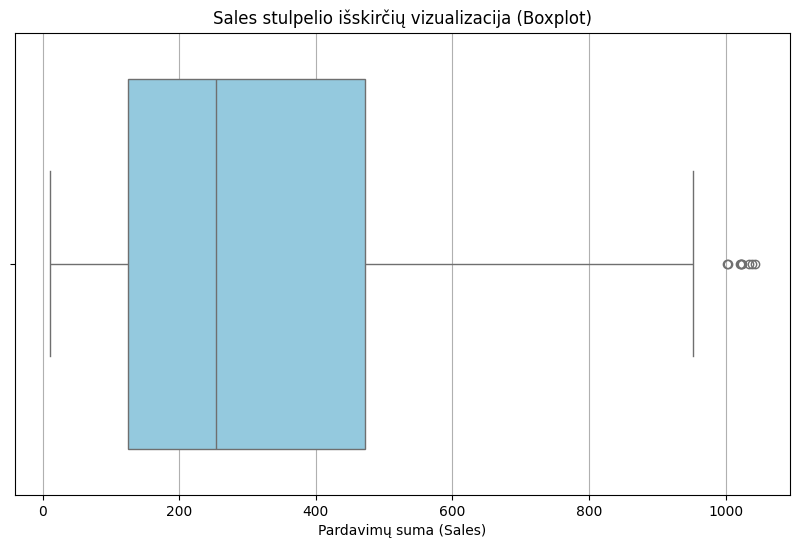

In [55]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Sales'], color='skyblue')
plt.title('Sales stulpelio išskirčių vizualizacija (Boxplot)')
plt.xlabel('Pardavimų suma (Sales)')
plt.show()

Modelio apibendrinimui ir patikimumui atlikau dar ir VIF testą, kad patikrinčiau ar nėra multikolinearumo tarp nepriklausomų kintamųjų. Skaičiavimas pateiktas žemiau, jis rodo kad dauguma kintamųjų puikūs, tačiau Hour (VIF ~11) parodė multikolinearumą. Dėl švarumo ir 'model assumption' sąlygų kintamąjį pašaliname ir modelį perskaičiuojame.

In [56]:
# Skaičiuojame VIF kiekvienam stulpeliui iš X (kurį naudojome OLS)
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                             Feature        VIF
2                               Hour  11.366136
0                         Unit price   4.903095
1                           Quantity   4.163564
13                   Payment_Ewallet   1.988037
3                       Branch_Cairo   1.957882
4                        Branch_Giza   1.937520
7   Product line_Fashion accessories   1.933015
8    Product line_Food and beverages   1.927015
12               Payment_Credit card   1.873423
11    Product line_Sports and travel   1.828750
6                        Gender_Male   1.825910
10   Product line_Home and lifestyle   1.786384
9     Product line_Health and beauty   1.781210
5               Customer type_Normal   1.760661


In [57]:

target = "Sales"
feature_cols = ["Unit price", "Quantity", "Branch", "Customer type", "Gender", "Product line", "Payment"]

X_raw = df[feature_cols].copy()
y = df[target].astype(float)

X = pd.get_dummies(X_raw, drop_first=True).astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_ols = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_ols).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     476.4
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                        12:40:04   Log-Likelihood:                -4656.9
No. Observations:                 800   AIC:                             9342.
Df Residuals:                     786   BIC:                             9407.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

In [58]:

X_test_ols = sm.add_constant(X_test)
pred_test = model.predict(X_test_ols)

r2 = r2_score(y_test, pred_test)
mae = mean_absolute_error(y_test, pred_test)
rmse = mean_squared_error(y_test, pred_test) ** 0.5

results = {"R2_test": r2, "MAE_test": mae, "RMSE_test": rmse}
print("\nModelio vertinimo metrikos:")
print(results)


Modelio vertinimo metrikos:
{'R2_test': 0.9014751606096123, 'MAE_test': 59.53709396800661, 'RMSE_test': 80.06202689467587}


Po kintamojo 'Hour' pašalinimo modelis pasikeitė labai minimaliai ir jo paaiškinimas nepasikeitė, todėl aprašymo nekartosiu.

Modelio prielaidų patikra:

1. Tiesiškumas (Linearity) - 'quantity; ir 'unit price' tiesiogiai lemia pardavimus;

2. Paklaidų nepriklausomumas (No Autocorrelation) - Durbin-Watson 2.084 rodo, kad autokoreliacijos nėra.

3. Homoskedastiškumas (Homoscedasticity) - deje, bet modelyje jis šiek tiek stebimas dėl didelių išskirčių ties 1000 valiutos vnt.

4. Paklaidų normalumas (Normality of Residuals) - Skew = -0.034. Paklaidos yra pasiskirsčiusios beveik tobulai simetriškai.

5. Multikolinearumo nebuvimas (No Multicollinearity) - Dauguma kintamųjų puikūs, tačiau Hour (VIF ~11) parodė multikolinearumą. Jo pašalinimas modelio tikslumo ir paklaidų reikšmingai nepakeitė.

6. Nėra stiprių išskirčių (Outliers) - išskirčių yra (virš 1000), ir jos stipriai padidino MAE paklaidą. Tačiau nusprendėme jas palikti, nes jos yra svarbi verslo informacijos dalis.

Apibendrinant modelį galima teigti, kad nors jis ir nėra puikus ir tenkinantis visas sąlygas, visgi statistiškai jis stiprus ir patikimas. Dėl egzistuojančių didelių išskirčių koeficientus reiktų vertinti atsargiai. Išskirtys nebuvo pašalintos iš duomenų, kadangi jos yra svarbios pirkėjo elgesiui aprašyti, ypač 'Normal' tipo pirkėjui, kurio imtyje išskirtys ir stebimos. Todėl plečiant darbą, būtų labai įdomu ir svarbu atlikti atskiras analizes 'Member' ir 'Normal' grupėms, tokiu atveju greičiausiai MME šiek tiek sumažėtų 'Members' grupėje ir modelis būtų truputį naudingesnis. Kaip jau išmokome - visi modeliai klaidingi, bet kai kurie gali būti naudingi. Ar naudingas šis (?) - verslui turbūt minimaliai, bet mokymuisi - neįkainojamas.



#### 7. Laiko eilučių analizė

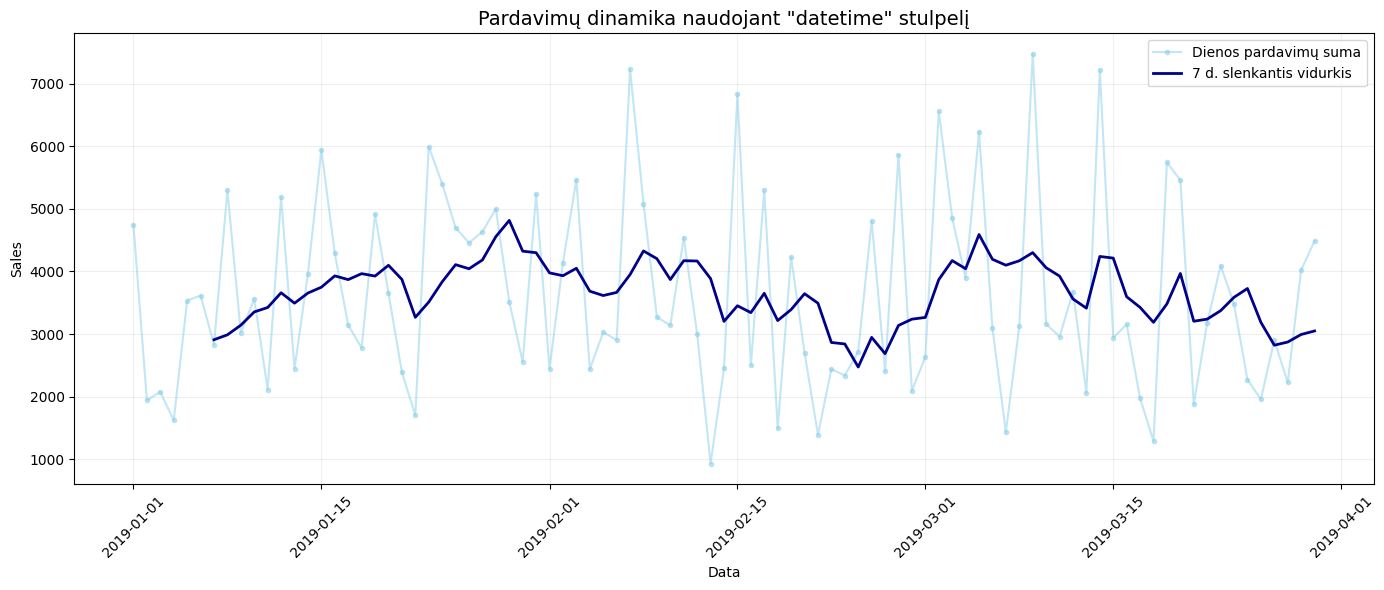

Paskutinė prognozuojama reikšmė (MA): 3050.78


In [59]:
# 1. Agreguojame pardavimus pagal dieną
# Naudojame .dt.date, kad sugrupuotume visas tos pačios dienos valandas į vieną tašką
daily_sales = df.groupby(df['datetime'].dt.date)['Sales'].sum().sort_index()

# 2. Slenkantis vidurkis (7 dienų)
window = 7
ts_ma = daily_sales.rolling(window=window).mean()

# 3. Vizualizacija
plt.figure(figsize=(14, 6))

# Tikrosios dienos reikšmės
plt.plot(daily_sales.index, daily_sales.values, label='Dienos pardavimų suma', 
         color='skyblue', alpha=0.5, marker='o', markersize=3)

# Slenkantis vidurkis
plt.plot(ts_ma.index, ts_ma.values, label=f'{window} d. slenkantis vidurkis', 
         color='darkblue', linewidth=2)

plt.title('Pardavimų dinamika naudojant "datetime" stulpelį', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, alpha=0.2)
plt.xticks(rotation=45) # Pasukame datas
plt.tight_layout()
plt.show()

# 4. Prognozės reikšmė
print(f"Paskutinė prognozuojama reikšmė (MA): {ts_ma.iloc[-1]:.2f}")

Šiame grafike matome agreguotų pardavimų analizę pagal laiką dienomis. Mūsų duomenys apima trumpą laiko tarpą (2019-01-01 - 2019-03-30), tai pirmasis metų ketvirtis. Turima informacija mums leidžia išanalizuoti tą pirmąjį ketvirtį ir atlikti paprastą prognozavimą ateičiai (šiuo atveju paskutinei ketvirčio dienai). 

Šviesi mėlyna linija mums rodo dienos pardavimų sumą, o tamsi mėlyna rodo septynių dienų slenkantį vidurkį. Iš pirmosios aiškiai matome didelius kasdienius pardavimų svyravimus nuo mažiau nei 1000 valiutos vnt iki 7000 per dieną. Tai labai didelis skirtumas, ir jis iš dalies paaiškina mūsų regresinės analizės didelę MAE (59) reikšmę. Net ir geras reikšmingas modelis sunkiai prisitaiko prie tokių didelių šuolių. Trys dideli pikai vasario pradžioje, vasario viduryje ir kovo viduryje, kylantys net virš 7000 mums vizualiai parodo, kur atsiranda išskirtys. Ir nors jie išbalansuoja vidurkius ir komplikuoja skaičiavimus, įneša didelę apyvartą ir yra labai svarbūs. 7 dienų slenkantis vidurkis „išlygina“ kasdienį triukšmą ir parodo tikrąją verslo būklę ir mums parodo, kad bendras pardavimų lygis išlieka stabilus. Nėra nei ryškaus augimo, nei kritimo. Verslas stabiliai laikosi tarp 3000 ir 4500 zonos pagal vidurkį. Matomas tam tikras cikliškumas (kreivei nežymiai nukritus mėnesio gale, pradžioje ji vėl atsistato), greičiausiai tai logiškas 'payday' reiškinys - žmonės taupo mėnesio gale, o po algos apsiperka stipriau. Nepanašu, kad būtų matomas aiškus cikliškumas pagal savaitės dienas, tačiau galime tai patikrinti vizualiai smulkiau.

Paskutinė prognozuojama reikšmė yra 3050.78 piniginių vnt, t.y. tikėtina, kad pagal turimus duomenis kovo 31 dieną prekybos centras turėtų suprekiauti už 3050.78 pinigų. Norint atlikti tikslesnę ir sudėtingesnę analizę reikėtų atsižvelgti į daugiau veiksnių, pvz. valstybines šventes, atostogų dienas, oro ir temperatūros permainas, praeitų metų apyvartą ir verslo augimo koeficientą, bei kitus. 

C:\Users\linke\AppData\Local\Temp\ipykernel_51540\313016482.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekday_analysis.index, y=weekday_analysis.values, palette='viridis')


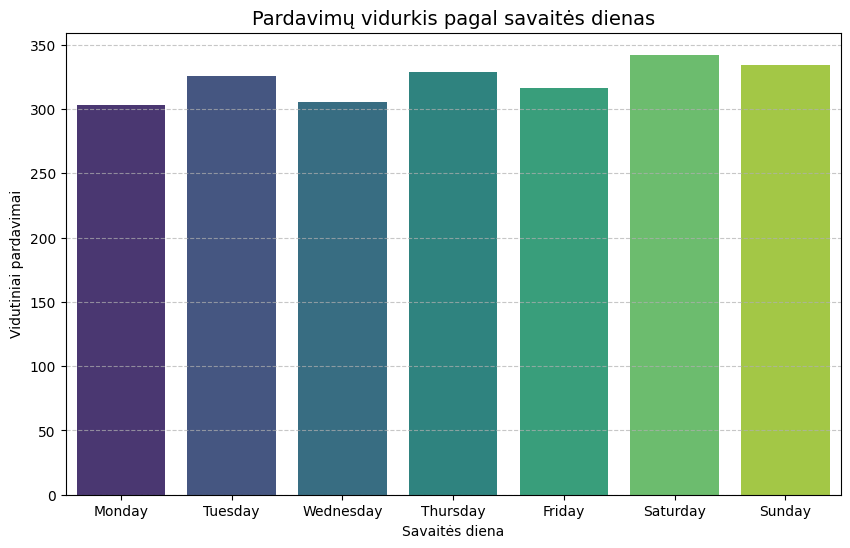

In [60]:

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_analysis = df.groupby('Weekday')['Sales'].mean().reindex(days_order)

plt.figure(figsize=(10, 6))
sns.barplot(x=weekday_analysis.index, y=weekday_analysis.values, palette='viridis')

plt.title('Pardavimų vidurkis pagal savaitės dienas', fontsize=14)
plt.ylabel('Vidutiniai pardavimai')
plt.xlabel('Savaitės diena')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Matomas labai nedidelis pokytis pagal savaitės dienas, kai tarp silpniausios dienos (pirmadienio) ir stipriausios dienos (šeštadienio) nėra nei 40 piniginių vnt. Skirtumai nereikšmingi.

#### 8. Išvados

- Apibendrinta EDA:

    - Duomenų imtis yra gana didelė, apimanti 1000 eilučių. Po duomenų sutvarkymo turime 19 stulpelių, iš kurių 10 yra skaitiniai, trūkstamų reikšmių nėra. Duomenys apima ketvirčio (beveik 3 mėnesių) prekybos centro pardavimus. 

    - Daugumos kintamųjų pasiskirstymas nėra normalusis, detaliai nagrinėto kintamojo 'Sales' pasiskirstymas yra dešinysis. Tačiau dėl didelės imties darome prielaidą, kad duomenys yra artimi normaliesiems, metodus pasirenkame atitinkamai.

    - Nustatytas stiprus multikolinearumas tarp finansinių rodiklių (Sales, cogs, gross income). Tai paaiškinama tiesiogine matematine priklausomybe ir fiksuota 5 % pelno marža.

    - Pardavimų apimtis stipriausiai koreliuoja su prekių kiekiu (Quantity), tuo tarpu kaina (Unit price) turi vidutinę įtaką. Tai rodo, kad krepšelio dydį labiau lemia perkamų vienetų skaičius, o ne pavienių prekių prabanga.


- CI interpretacija (Klientų pasitenkinimas): 

    - Apskaičiuotas 95 % pasikliautinis intervalas [6.87, 7.08] pirkėjų įvertinimų vidurkiui (vidurkis ~6.97) patvirtina, kad bendras klientų pasitenkinimas yra stabilus ir teigiamas. Mažas intervalo plotis rodo, kad ši imtis gerai reprezentuoja bendrą pirkėjų nuomonę.

- Hipotezės ir jų interpretacija:

    - Darbe tikrinome dvi hipotezes:
    
    H0: Vidutinės pirkimo sumos (Sales) tarp „Member“ ir „Normal“ klientų grupių nesiskiria.

    Ha: Vidutinės pirkimo sumos (Sales) tarp „Member“ ir „Normal“ klientų grupių statistiškai reikšmingai skiriasi.

    T-testo p-reikšmė 0.0596 ir Mann-Whitney p-reikšmė 0.0812 parodė, kad nors ir egzistuoja nemažas skirtumas tarp 'Member' ir 'Normal' vidurkių (Member vidurkis: 335.74, Normal vidurkis: 306.37) bei medianų (Member mediana: 271.95, Normal mediana: 225.79) kol kas šis skirtumas neperžengia statistinio reikšmingumo ribos.

    Išvada: Narystės statusas turi teigiamą tendenciją pirkimų sumai, tačiau didelė duomenų sklaida abiejose grupėse neleidžia teigti, kad šis skirtumas yra dėsningas visiems klientams.

- Apibendrinta regresinė analizė:

    - Metrikos:

        R2 (Determinacijos koeficientas 0.901): Sukurtas Test modelis paaiškina 90.1%  pardavimų svyravimų. 
        
        MAE (Mean Absolute Error 59.537): Vidutinė prognozės paklaida yra 59.5 valiutos vienetų į vieną ar kitą pusę.

    - Koeficientai (statistiškai reikšmingi tik du kintamieji):

        - Quantity koef=58: laikant kitus kintamuosius pastoviais, kiekvienas papildomas nupirktas vienetas 'Quantity' padidina bendrą pirkimo sumą vidutiniškai 58 valiutos vienetais.

        - Unit price koef=5.8: laikant kitus kintamuosius pastoviais, kiekvienas vieneto kainos padidėjimas 1 valiutos vienetu, padidina bendrą pirkimo sumą 5.8 valiutos vienetais.
    Išvada: Svarbiausi veiksniai, darantys įtaką pardavimų sumai, yra parduotų prekių kiekis ir vieneto kaina. Tai rodo, kad pardavimų strategijoje pagrindinis dėmesys turėtų būti skiriamas krepšelio dydžio (kiekio) didinimui, nes tai daro reikšmingiausią įtaką galutinei pajamų sumai.

- Laiko eilučių analizė:

    Laiko eilučių analizė pirmam metų ketvirčiui rodo, kad nors prekybos centro pardavimuose yra didelių šuolių ir dienos pardavimų diapazonas labai platus, vidutinis septynių dienų slenkantis grafikas rodo stabilius ir net stacionarius pardavimus tarp 3000 - 4500 pagal vidurkį. Esamas verslo modelis veiksmingas ir sistemingai pritraukia stabilias pajamas. Didelių dėsningumų pardavimuose nematyti, tačiau matomas logiškas pakritimas mėnėsio gale, sugrįžtantis į stabilią kreivę mėnesio pradžioje po atlyginimų išmokėjimo. Savaitės dienos reikšmingos įtakos pardavimams nedaro. 

    Mūsų prognozuoti pardavimai 2019 kovo 31 dienai (3050.78) atitinka bendrą laiko analizės vaizdą, t.y. patenka į vidutinių dienos pardavimų lauką, atitikdamas žemesnius pardavimus, kaip ir matome kiekvieno mėnesio pabaigoje.

- Rekomendacijos verslui:

    - Jau veikiantis verslo modelis yra veiksmingas ir atneša stabilias pajamas, pasitenkinimo rodiklis (6.97 - vertinama vidutiniškai, bet stabiliai) tai tik papildo. Norint didinti pardavimus, svarbiausia reikia susitelkti į nuperkamų prekių kiekį - atlikta analizė tai puikiai iliustruoja, kadangi krepšelio padidėjimas vienetu stipriai padidina bendrą sumą.

    - Didesnė vieneto kaina taip pat didina bendras pajamas, tad nedidelis kainų padidinimas galėtų padidinti ir bendras pajamas (bei pelną, kadangi cogs nedidėja). Tačiau čia reikėtų atlikti detalesnę analizę ir prognozę. Per didelis kainų išpūtimas gali būti žalingas ir sumažinti perkamų prekių kiekį, taip sumažinant ir bendrus pardavimus. Verta apsvarstyti brangesnių / kokybiškesnių prekių įvedimą, tačiau vėlgi būtų reikalinga detalesnė analizė, įtraukiant cogs ir kitus kintamuosius.

    - Nors lojalumo programa kol kas nėra statistiškai reikšminga, visgi stebimas didesnis krepšelio svoris ir stabilesnis pirkimas tarp 'Member' narių, tuo tarpu 'Normal' pirkimuose matome daugiau atsitiktinių pirkimų. Norint sustiprinti lojalumo programą ir pakelti krepšelio svorį tarp 'Member' narių, būtų vertinga atlikti detalesnę kliento ir produkto analizę, bei pasiūlyti programas, skatinančias 'Members' pirkti daugiau brangesnių prekių.